# Single clustering for cross-modality alignment

This notebook prepares one spatial transcriptomics sample for cross-modality
alignment. It accepts either AnnData/H5AD or a paired metadata/expression CSV
input, runs single-sample BANKSY, optionally applies boundary-aware refinement,
and writes the canonical labels `cluster_raw`, `cluster_refined`, and `cluster`.

The example is the adult mouse brain MERFISH S2R1 sample (83,546 cells and 649
measured genes). The resulting `AnnData` is the direct input to the ST-to-Allen
CCF notebook; there is no intermediate research-script CSV contract.

## Installation and data

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,atlas,tutorial]"
```

Download the MERFISH Mouse Brain Receptor Map from
[Vizgen](https://info.vizgen.com/mouse-brain-map). Put either input form in
`data/cross_modality/mouse_brain/merfishS2/`, or set
`SPALIGNDE_ST_DATA_DIR` to another directory.

| Input form | Required files | Required fields |
|---|---|---|
| AnnData | `merfishS2_single.h5ad` | cell-by-gene `X`; finite `(n_obs, 2)` coordinates in `obsm["spatial"]`, or numeric `obs["x"]` and `obs["y"]` |
| CSV | `cell_metadata_S2R1.csv` and `cell_by_gene_S2R1.csv` | metadata: unique `cell_id`, numeric `x`, `y`; expression: the same `cell_id` values plus numeric, non-negative gene columns |

Set `SPALIGNDE_SINGLE_INPUT=csv` to exercise the CSV route. Both routes are
normalized by `spAlignDE.load_single_sample_data` to the same AnnData contract.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import spAlignDE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
public_data_dir = PROJECT_ROOT / "data" / "cross_modality" / "mouse_brain" / "merfishS2"
DATA_DIR = Path(os.environ.get("SPALIGNDE_ST_DATA_DIR", public_data_dir)).expanduser()

OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "atlas" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

INPUT_MODE = os.environ.get("SPALIGNDE_SINGLE_INPUT", "h5ad").strip().lower()

if INPUT_MODE in {"h5ad", "anndata"}:
    input_adata = spAlignDE.load_single_sample_data(DATA_DIR / "merfishS2_single.h5ad")
elif INPUT_MODE == "csv":
    input_adata = spAlignDE.load_single_sample_data(
        DATA_DIR / "cell_metadata_S2R1.csv",
        expression_csv=DATA_DIR / "cell_by_gene_S2R1.csv",
    )
else:
    raise ValueError("SPALIGNDE_SINGLE_INPUT must be 'h5ad' or 'csv'.")

print(f"Input mode: {INPUT_MODE}")
print(f"Input AnnData: {input_adata.n_obs:,} cells × {input_adata.n_vars:,} genes")

Input mode: h5ad
Input AnnData: 83,546 cells × 649 genes


## Run single-sample BANKSY

`banksy_lambda=0.8` and `resolution=1.2` reproduce the setting used for the
paper's S2R1 atlas experiment. BANKSY incorporates each cell's expression and
spatial-neighborhood features. Boundary-aware refinement uses fewer neighbors
near the tissue edge so thin anatomical structures are not erased by a global
majority vote.

This is a fresh package run. The notebook writes its clustered AnnData once;
the following alignment notebook reads that file as the explicit handoff
between the two workflow steps.

  from pkg_resources import get_distribution, DistributionNotFound



Median distance to closest cell = 12.278203930723837

---- Ran median_dist_to_nearest_neighbour in 0.12 s ----



---- Ran generate_spatial_distance_graph in 0.51 s ----



---- Ran row_normalize in 0.15 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 1.46 s ----



---- Ran generate_spatial_distance_graph in 0.90 s ----



...

,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata
nonspatial_pc20_nc0.00_r1.20,nonspatial,0.0,20,1.2,31,"Label object:\nNumber of labels: 31, number of...",[[[View of AnnData object with n_obs × n_vars ...
scaled_gaussian_pc20_nc0.80_r1.20,scaled_gaussian,0.8,20,1.2,25,"Label object:\nNumber of labels: 25, number of...",[[[View of AnnData object with n_obs × n_vars ...


Anndata AxisArrays with keys: reduced_pc_20


  ax.scatter(adata_temp.obs[coord_keys[0]].values,


Anndata AxisArrays with keys: reduced_pc_20


Mode: fresh package run
Raw clusters: 25
Refined clusters: 25


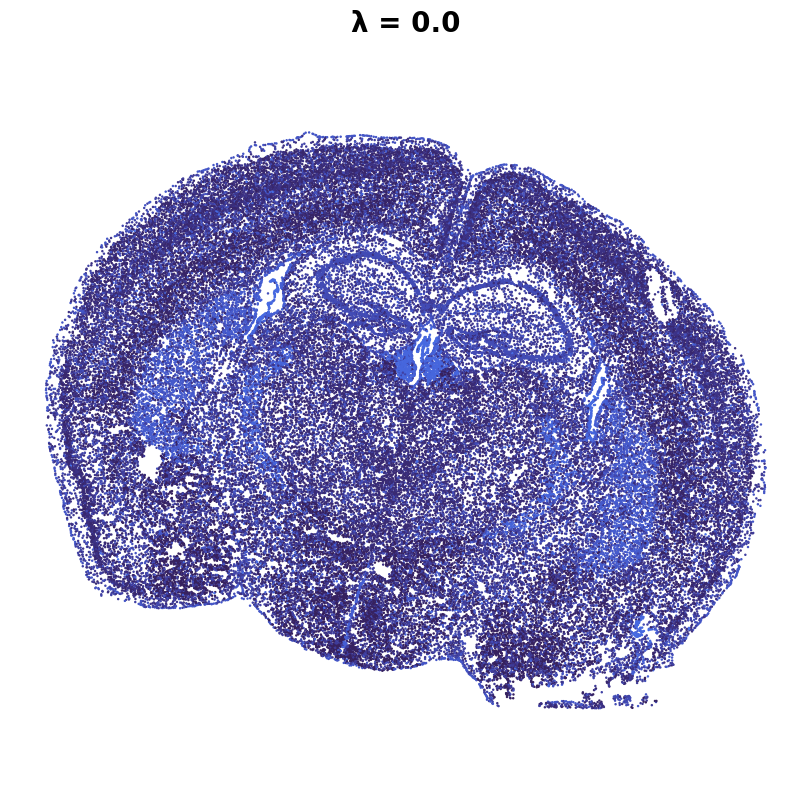

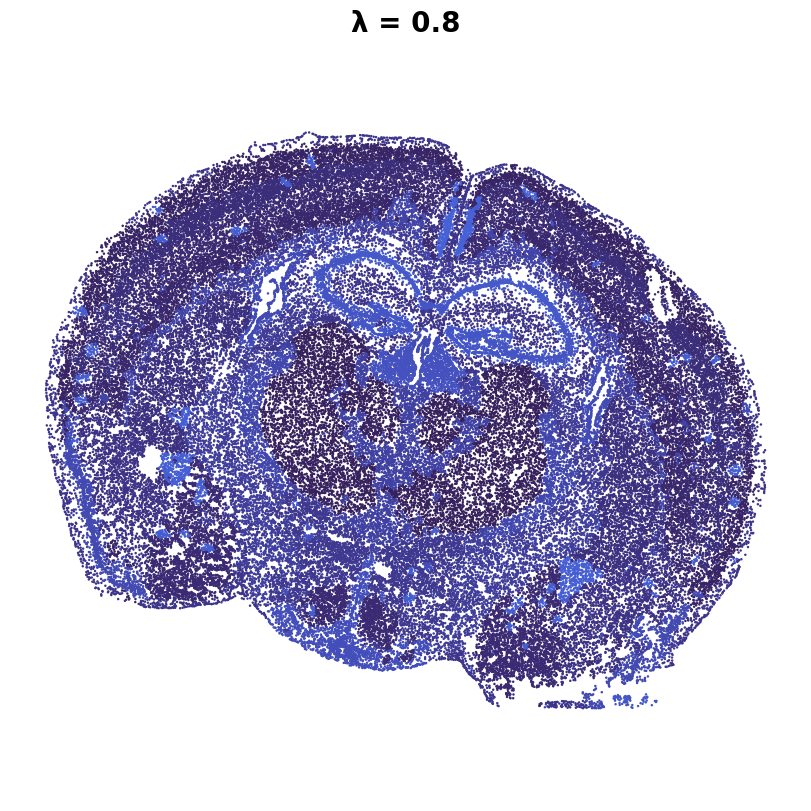

In [2]:
config = spAlignDE.SingleClusteringConfig(
    num_neighbors=30,
    banksy_lambda=0.8,
    resolution=1.2,
    max_m=1,
    decay="scaled_gaussian",
    refine_boundaries=True,
)

clustered = spAlignDE.cluster_single(
    input_adata,
    config=config,
    banksy_output_dir=OUTPUT_DIR / "banksy_diagnostics",
)

spAlignDE.validate_single_sample_anndata(
    clustered,
    cluster_key="cluster",
    require_cluster=True,
)
print("Mode: fresh package run")
print("Raw clusters:", clustered.obs["cluster_raw"].nunique())
print("Refined clusters:", clustered.obs["cluster_refined"].nunique())

### How to adapt the clustering parameters

Tune clustering before changing alignment parameters. Keep the random seed and
all other settings fixed while comparing a small grid of candidate values.

- `num_neighbors`: increasing it summarizes a broader spatial neighborhood and
  usually smooths structures; reduce it if thin domains disappear.
- `banksy_lambda`: increasing it gives spatial-neighborhood information more
  influence relative to each observation's own expression.
- `resolution`: increasing it usually produces more Leiden clusters. Reject
  settings that create many tiny sample-specific fragments or merge clearly
  distinct spatial domains.
- `snn_neighbors` and `harmony_theta` (joint clustering only): the former
  broadens graph connectivity and the latter strengthens sample correction.
  Do not erase biological differences merely to maximize shared labels.
- `refine_boundaries`: compare `cluster_raw` and `cluster_refined` spatially.
  Refinement should remove isolated boundary noise without erasing narrow
  structures.

Select a configuration using spatial coherence, boundary preservation, cluster
size and coverage in every required sample. Cluster integer values are
arbitrary and may be renumbered across runs; compare memberships and maps, not
label numbers. The website **Parameter Tuning Guide** gives the complete
clustering-to-alignment tuning order.

## Inspect raw and refined spatial structures

Both panels share one cluster-color map. This makes boundary corrections
visible without changing cluster identity colors. For paper-scale point
clouds, the scatter layer is rasterized inside the SVG to keep the vector file
responsive while retaining editable axes and text.

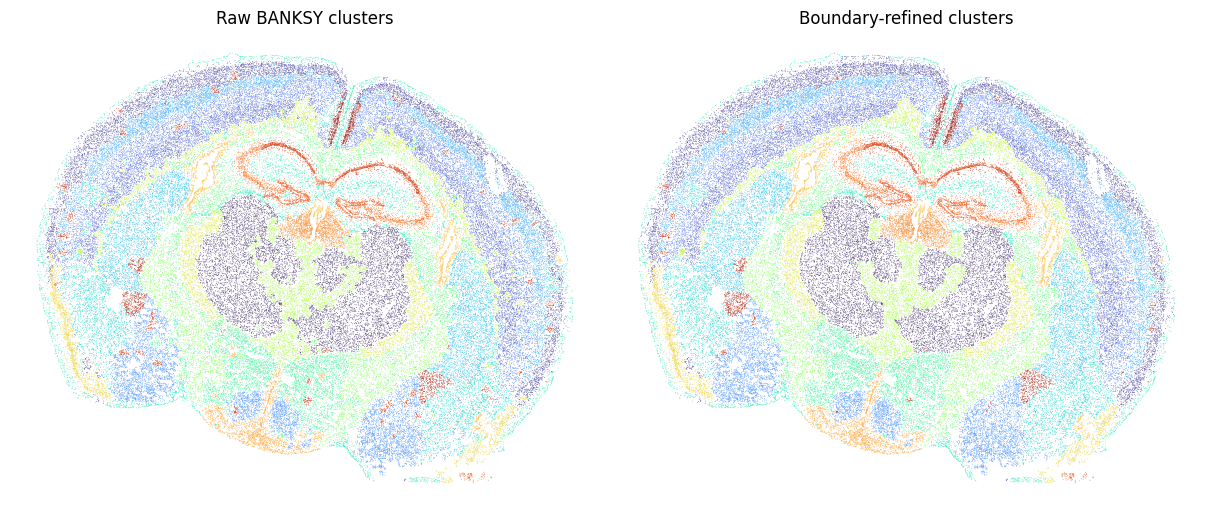

In [3]:
fig, axes = spAlignDE.plot_single_cluster_refinement(
    clustered,
    point_size=0.35,
    alpha=0.85,
    figsize=(12, 5.5),
)
fig.savefig(FIGURE_DIR / "single_clustering_raw_vs_refined.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "single_clustering_raw_vs_refined.svg", bbox_inches="tight")
plt.show()

## Save the canonical clustered AnnData

The original expression matrix and `obsm["spatial"]` remain unchanged. The
three package-owned columns are:

- `cluster_raw`: selected BANKSY labels;
- `cluster_refined`: boundary-refined labels; and
- `cluster`: labels selected for downstream alignment.

Package provenance is stored only under `adata.uns["spAlignDE"]`.

In [4]:
clustered_path = OUTPUT_DIR / "merfish_S2R1_single_clustered.h5ad"
clustered.write_h5ad(clustered_path)

summary = pd.DataFrame(
    {
        "value": [
            f"{clustered.n_obs:,}",
            f"{clustered.n_vars:,}",
            clustered.obs["cluster_raw"].nunique(),
            clustered.obs["cluster_refined"].nunique(),
            "cluster_raw, cluster_refined, cluster",
        ]
    },
    index=["cells", "genes", "raw clusters", "refined clusters", "output labels"],
)
display(summary)
print("Saved: tutorials/cross_modality/atlas/output/merfish_S2R1_single_clustered.h5ad")

,value
cells,"83,546"
genes,649
raw clusters,25
refined clusters,25
output labels,"cluster_raw, cluster_refined, cluster"


Saved: tutorials/cross_modality/atlas/output/merfish_S2R1_single_clustered.h5ad


## Next step

Open **ST-to-Allen-CCF alignment — MERFISH adult mouse brain**. It reads this
clustered AnnData, builds expression-based coarse-to-fine structure levels,
aligns S2R1 to Allen CCF slice 675, and transfers atlas labels to every cell.